# Predictive Alerting for Cloud Metrics
## Part 1: Exploratory Data Analysis

**Task:** Implement a model that predicts whether an incident will occur within the next H time steps based on the previous W steps of one or more time-series metrics.

Use a sliding-window formulation and train the model using any standard machine-learning framework.

The applicant may use any suitable public dataset or generate a synthetic time series with labeled incident intervals (e.g. anomalies or threshold breaches).

The emphasis is on correct problem formulation, model selection, training, and evaluation rather than dataset complexity or model size. The solution should include a clear description of the modeling choices, the evaluation setup (including alert thresholds and metrics), and an analysis of the results.

During follow-up, the applicant should be able to explain the design decisions, discuss limitations, and outline how the approach could be adapted to a real alerting system. Preferably, solutions should be provided as a link to a public GitHub repository.

**Dataset:** NAB (Numenta Anomaly Benchmark) — real AWS CloudWatch metrics
including CPU utilization, disk writes, network traffic, and autoscaling events.
Anomaly labels from `combined_windows.json`.

**This notebook covers:**
1. Data loading and inspection
2. Anomaly visualization across all metric types
3. Timestamp regularity check (filtering unreliable files)
4. Seasonal decomposition (daily patterns in cloud metrics)
5. Anomaly distribution analysis
6. Selection of files suitable for supervised learning


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import download_nab_data, load_labeled_series, get_interval_minutes
from src.config import DATA_DIR, LABELS_PATH

download_nab_data()

files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
print(f"Downloaded {len(files)} CloudWatch metric files")


Downloaded 17 CloudWatch metric files


In [2]:
def plot_metric_eda(df, file_name):
    """Time series plot with anomaly zones + value distribution."""
    sns.set_style("whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 3))

    # Time series
    
    ax1.plot(df['timestamp'], df['value'], color='darkblue', linewidth=0.5)
    diff = df['is_anomaly'].diff()
    starts = df[diff == 1]['timestamp'].tolist()
    ends = df[diff == -1]['timestamp'].tolist()
    if df['is_anomaly'].iloc[0] == 1:
        starts.insert(0, df['timestamp'].iloc[0])
    if df['is_anomaly'].iloc[-1] == 1:
        ends.append(df['timestamp'].iloc[-1])
    for s, e in zip(starts, ends):
        ax1.axvspan(s, e, color='purple', alpha=0.3)
    ax1.tick_params(axis='x', labelsize=8, rotation=30)
    ax1.set_title(f"Anomaly Zone for {file_name}", fontsize=10)
    ax1.legend(['Value', 'Anomaly zone'], loc='upper right', fontsize=8)

    # Distribution
    num_bins = 50
    sns.histplot(df['value'], bins=num_bins, kde=True, ax=ax2, color='green')

    counts, bin_edges = np.histogram(df['value'], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    threshold = max(1, len(df) * 0.01) 
    small_bins_mask = (counts > 0) & (counts <= threshold)
    ax2.scatter(bin_centers[small_bins_mask], 
                counts[small_bins_mask] + (ax2.get_ylim()[1] * 0.02), 
                color='navy', marker='v', s=30, label='Rare values (Heavy Tail)')
    ax2.set_title("Value Distribution (Looking for Heavy Tails)", fontsize=12)
    ax2.set_xlabel(f"Value in {file_name}")

    plt.tight_layout()
    plt.show()


plotting chart...: ec2_cpu_utilization_24ae8d.csv


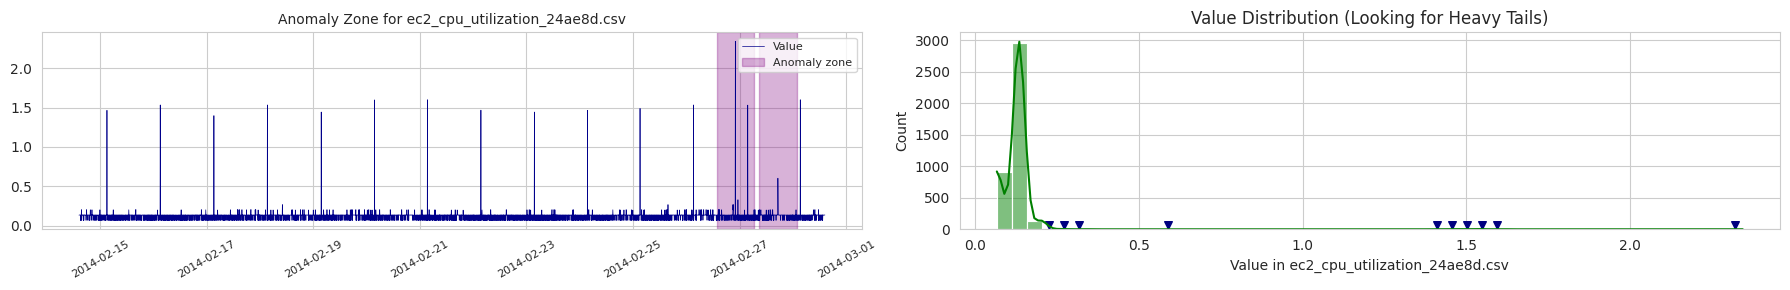

plotting chart...: ec2_cpu_utilization_53ea38.csv


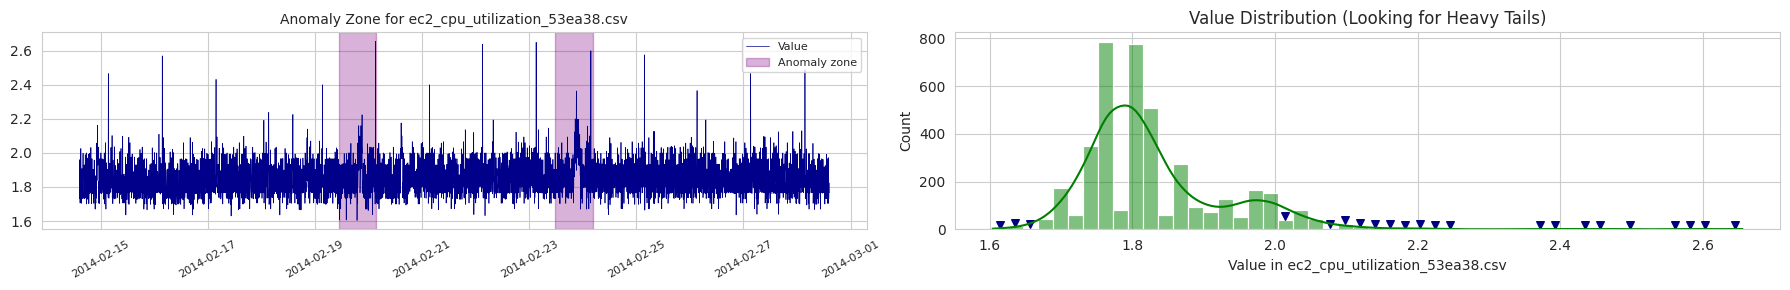

plotting chart...: ec2_cpu_utilization_5f5533.csv


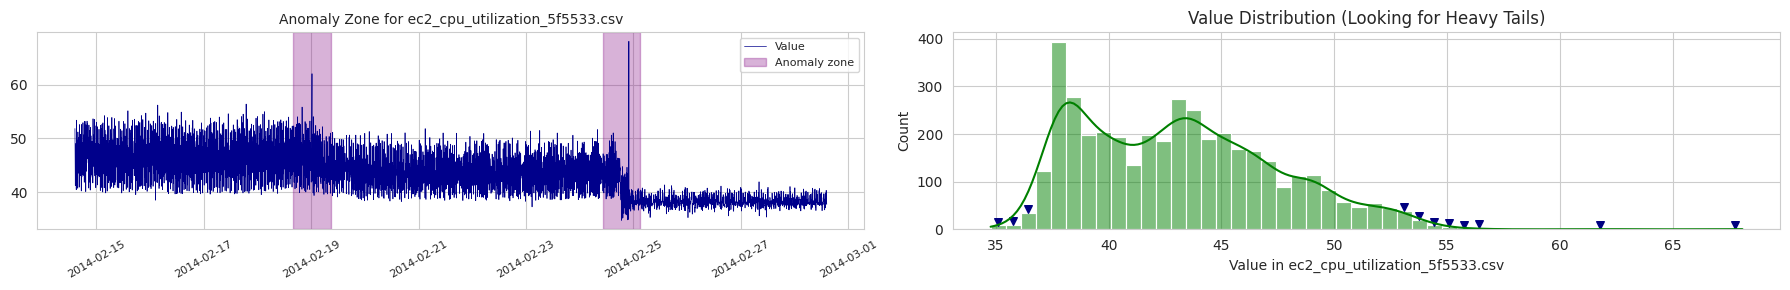

plotting chart...: ec2_cpu_utilization_77c1ca.csv


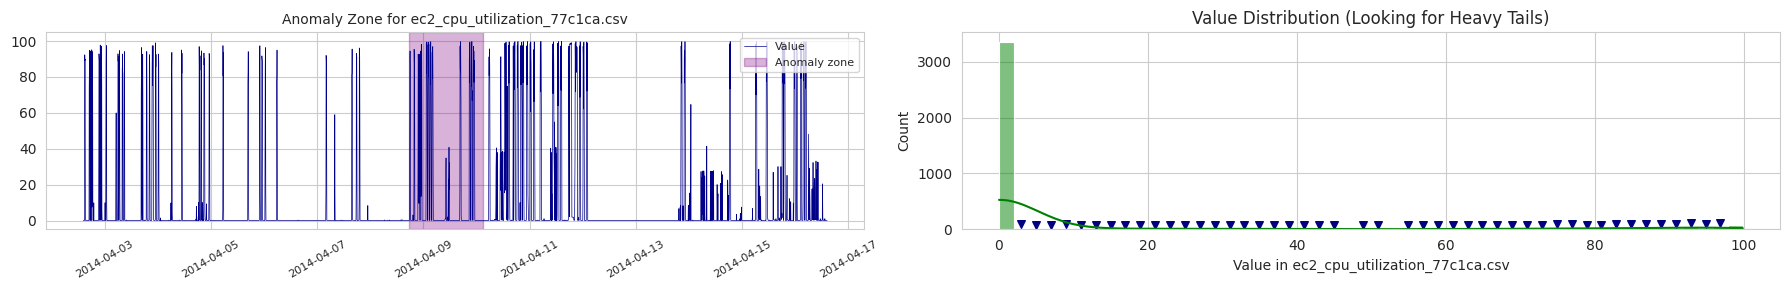

plotting chart...: ec2_cpu_utilization_825cc2.csv


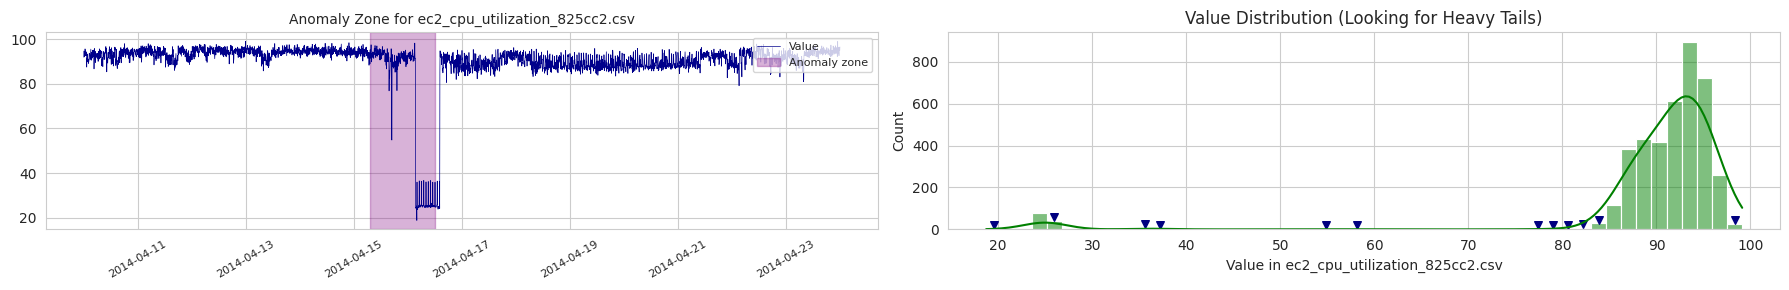

plotting chart...: ec2_cpu_utilization_ac20cd.csv


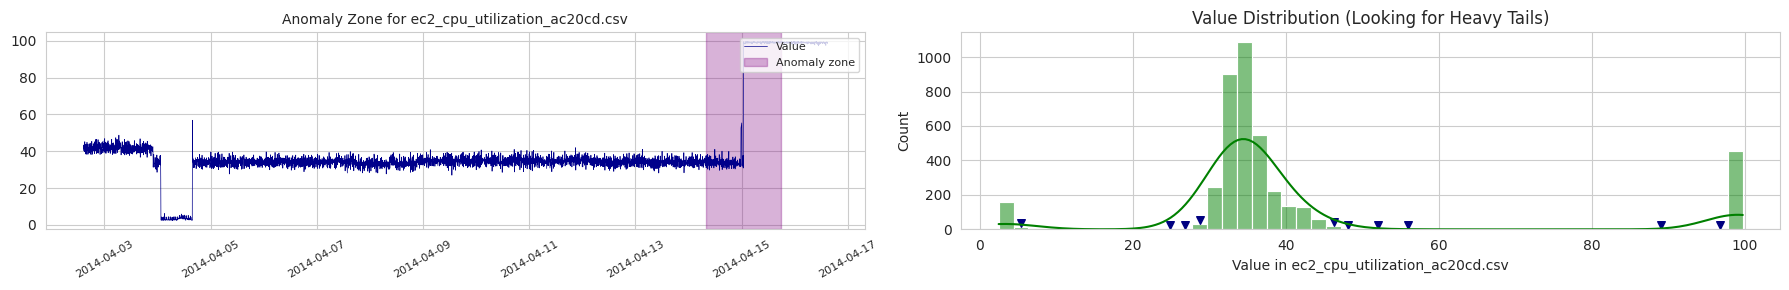

plotting chart...: ec2_cpu_utilization_c6585a.csv


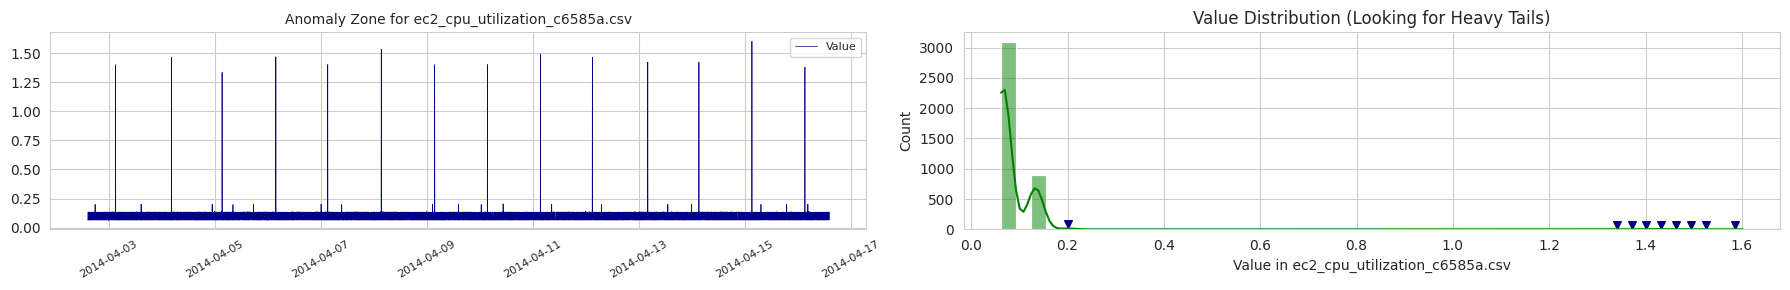

plotting chart...: ec2_cpu_utilization_fe7f93.csv


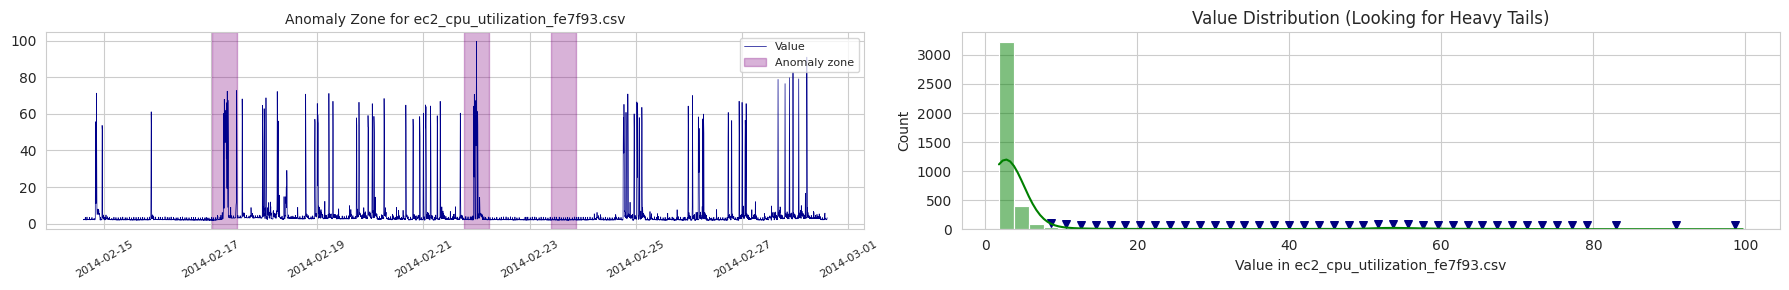

plotting chart...: ec2_disk_write_bytes_1ef3de.csv


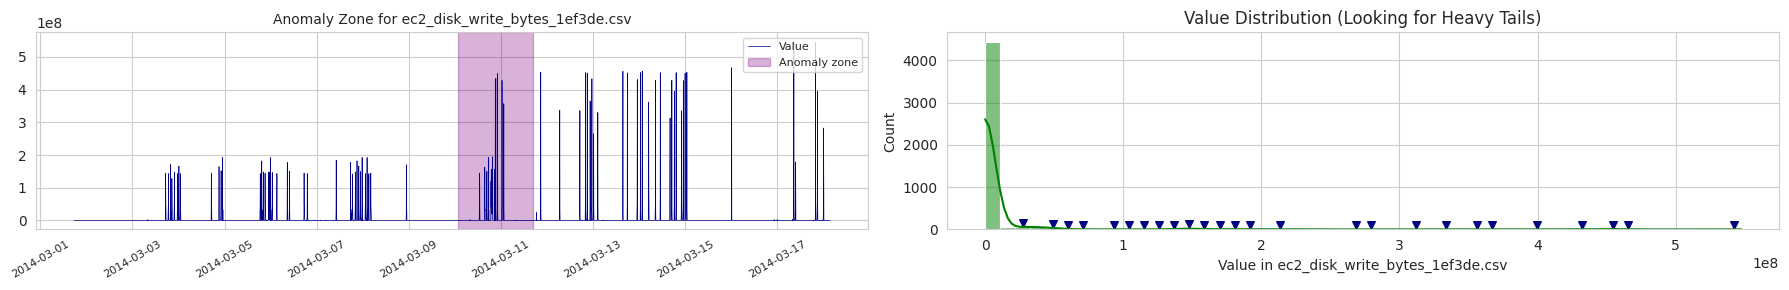

plotting chart...: ec2_disk_write_bytes_c0d644.csv


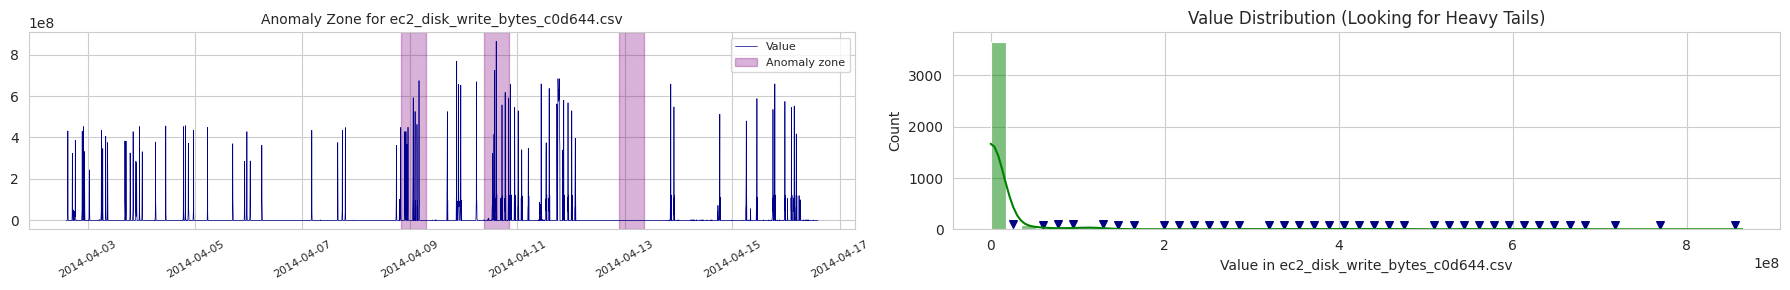

plotting chart...: ec2_network_in_257a54.csv


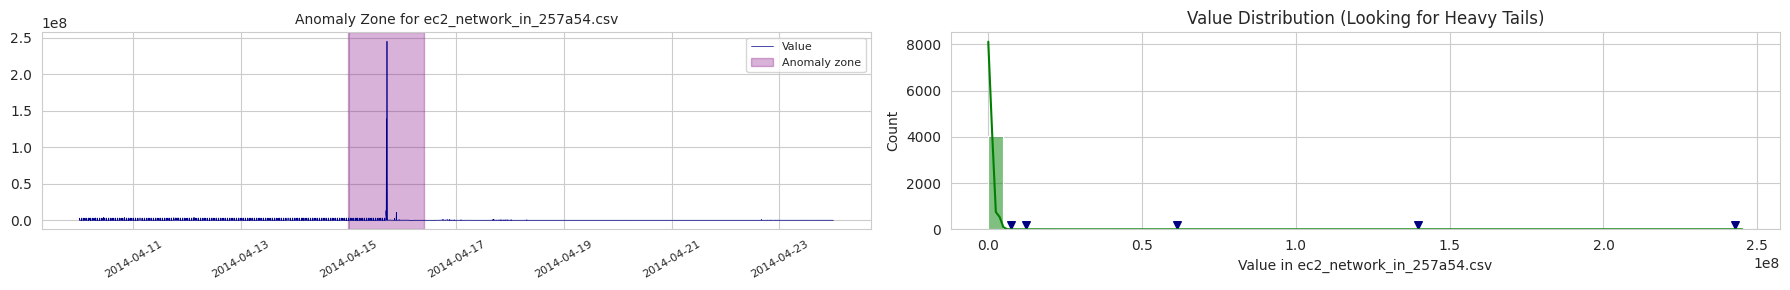

plotting chart...: ec2_network_in_5abac7.csv


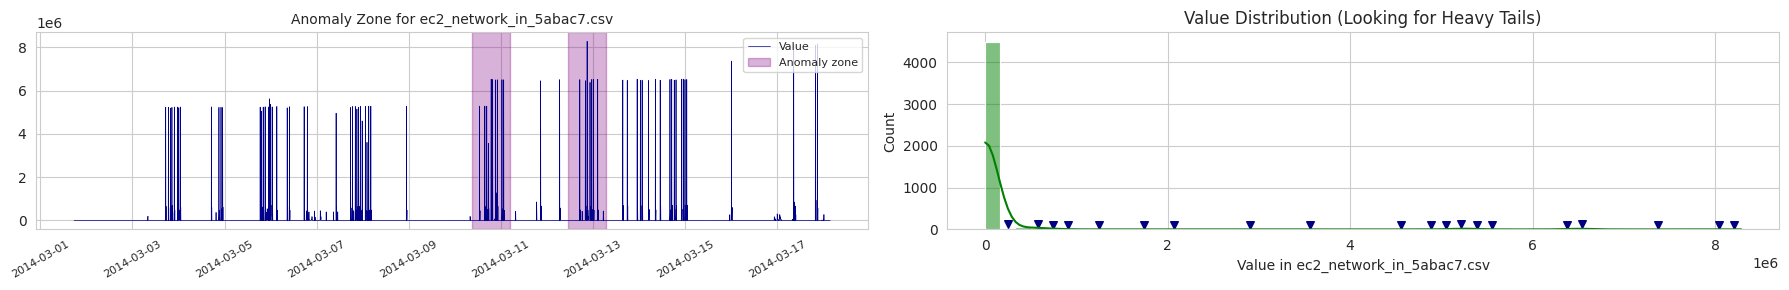

plotting chart...: elb_request_count_8c0756.csv


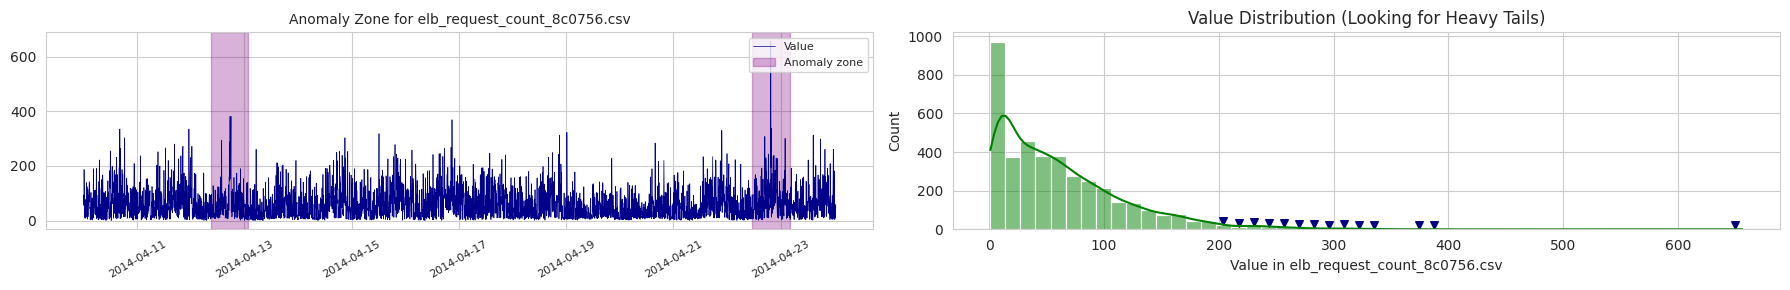

plotting chart...: grok_asg_anomaly.csv


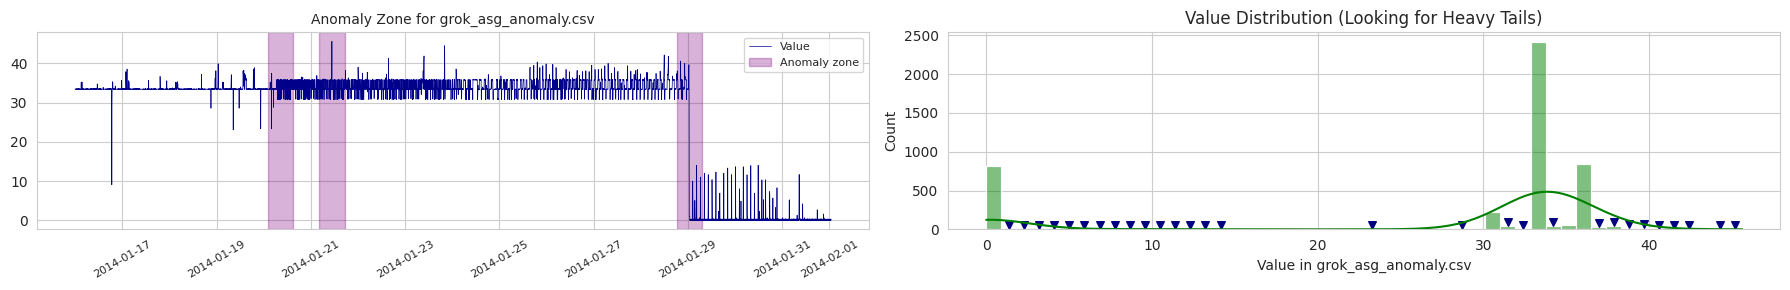

plotting chart...: iio_us-east-1_i-a2eb1cd9_NetworkIn.csv


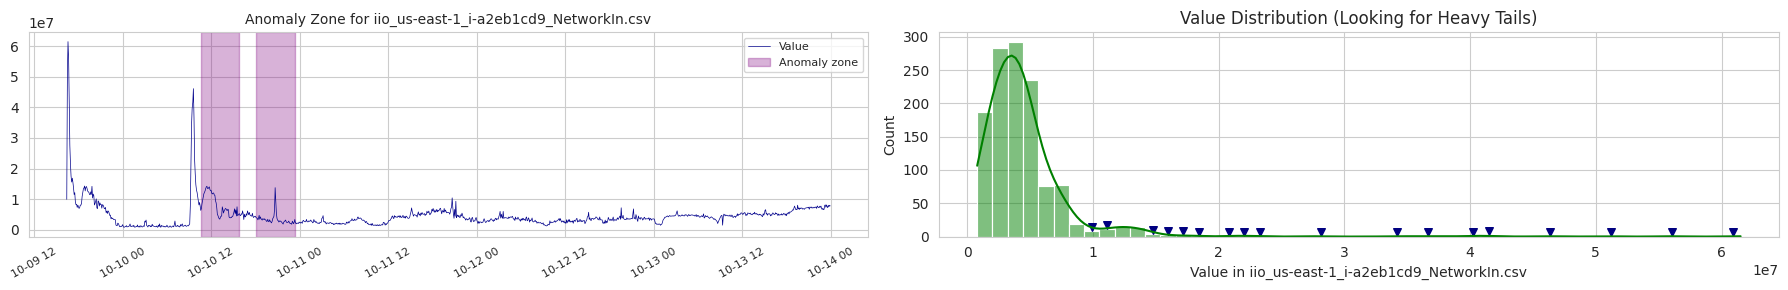

plotting chart...: rds_cpu_utilization_cc0c53.csv


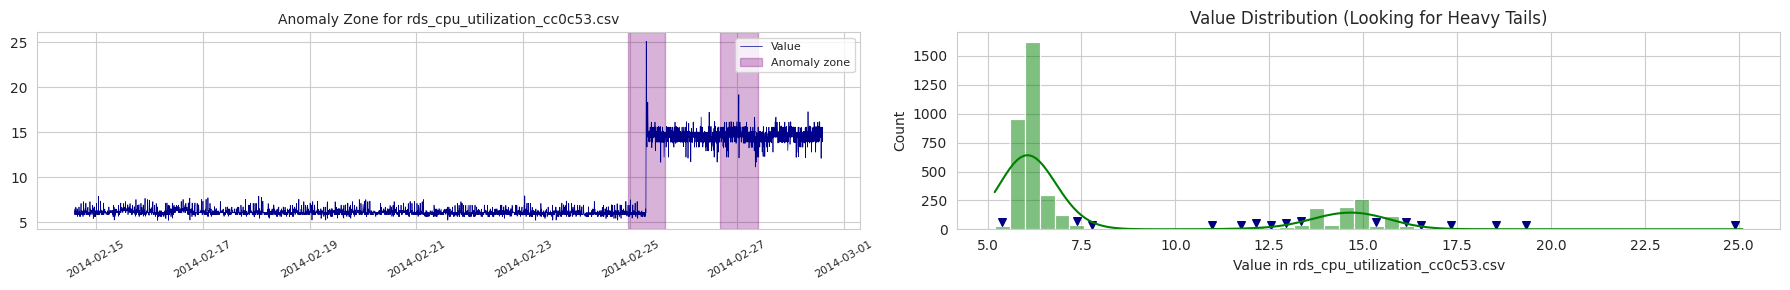

plotting chart...: rds_cpu_utilization_e47b3b.csv


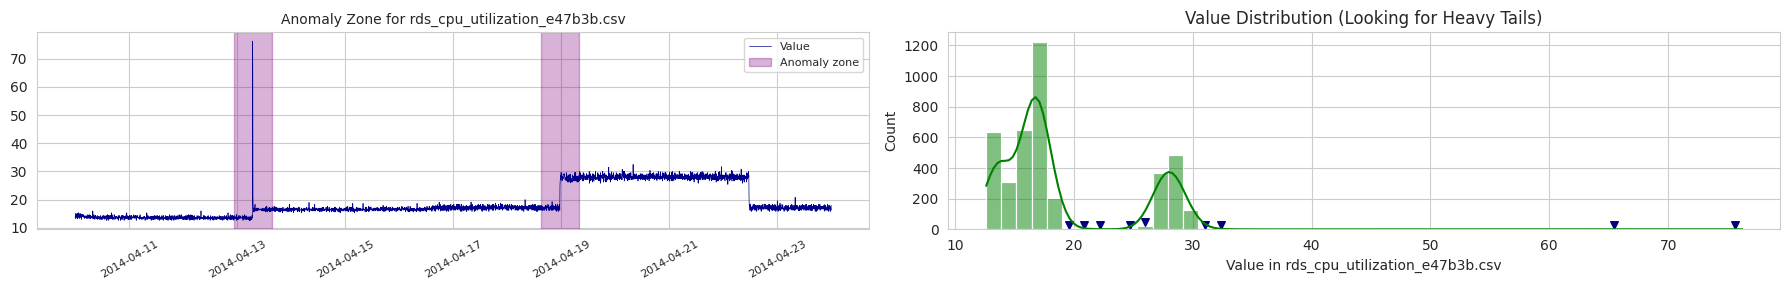

In [3]:
for file_name in files:
    path = os.path.join(DATA_DIR, file_name)
    df = load_labeled_series(path)
    print(f"plotting chart...: {file_name}")
    plot_metric_eda(df, file_name)


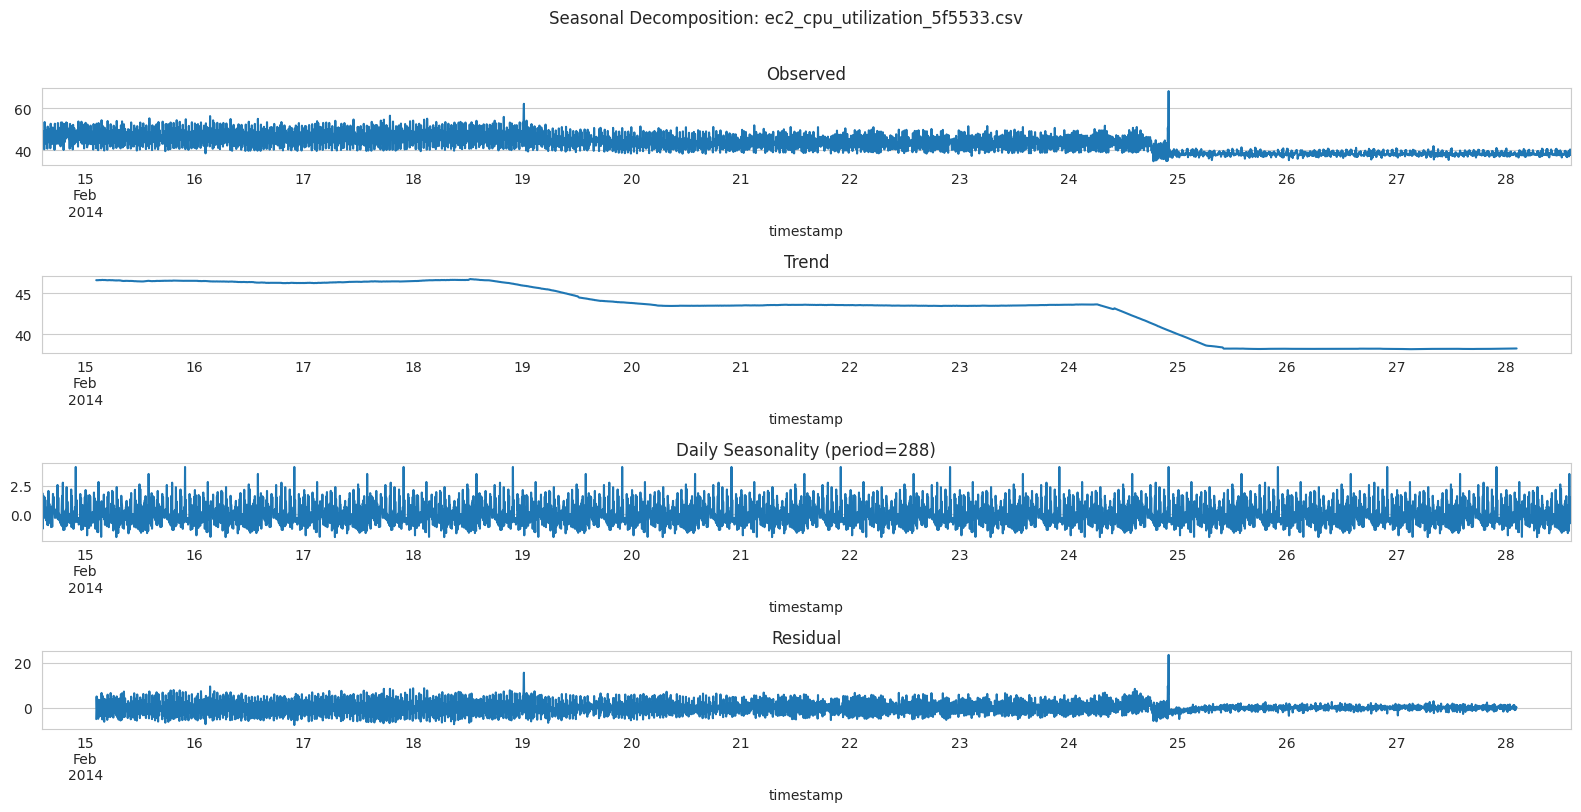

  file:ec2_cpu_utilization_5f5533.csv         
  Original std:                  4.30         
  Residual std:                  2.77
  Seasonality + trend explain:  36% of variance


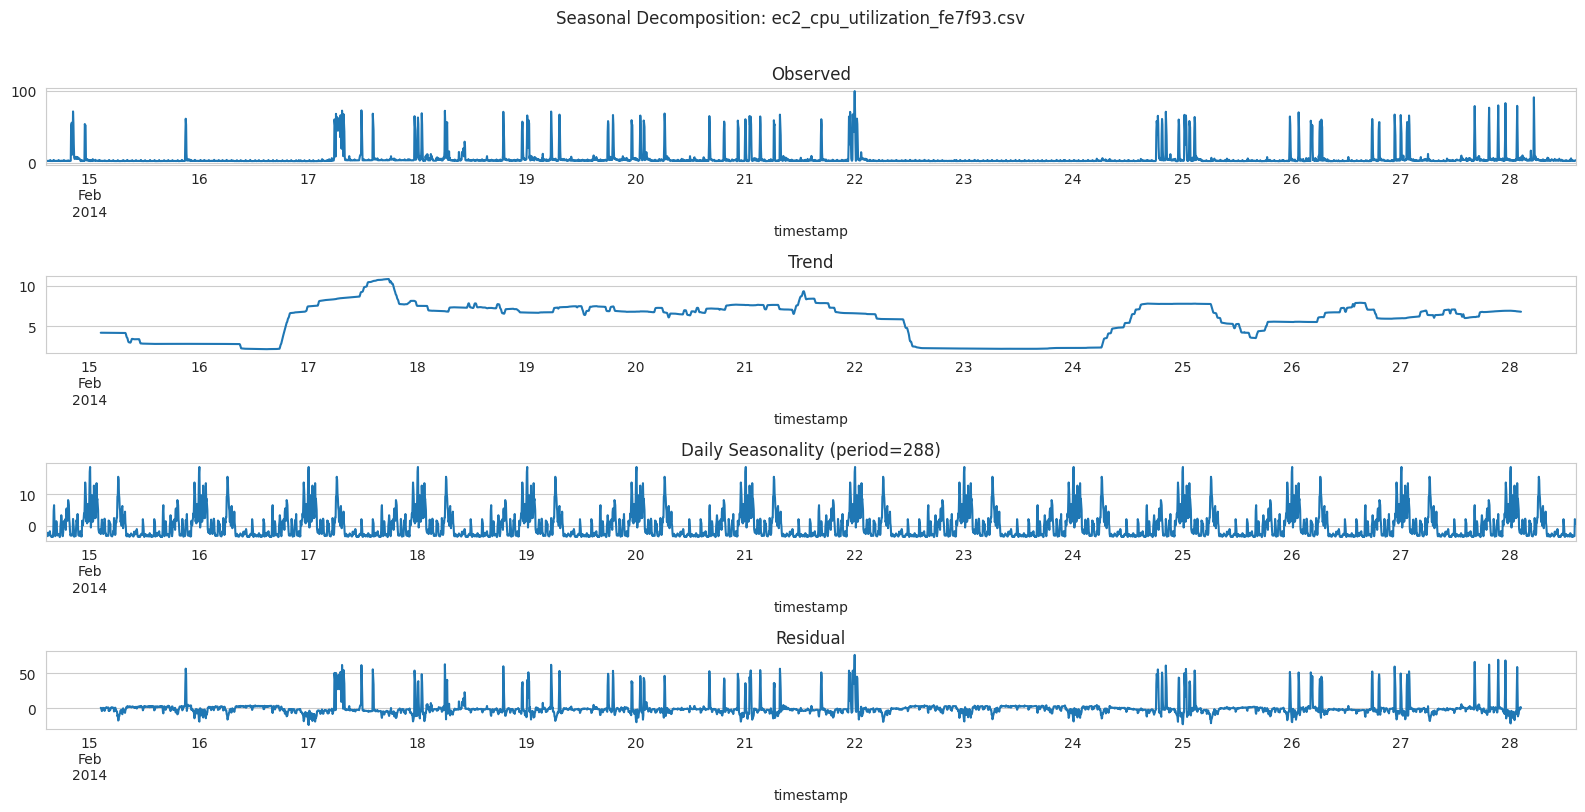

  file:ec2_cpu_utilization_fe7f93.csv         
  Original std:                 11.81         
  Residual std:                 10.91
  Seasonality + trend explain:   8% of variance


In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

def plot_decomposition(file_name):
    path = os.path.join(DATA_DIR, file_name)
    df = load_labeled_series(path).set_index('timestamp')

    # period=288: 24h * 60min / 5min = 288 points per day
    decomp = seasonal_decompose(df['value'], model='additive', period=288)

    fig, axes = plt.subplots(4, 1, figsize=(16, 8))
    decomp.observed.plot(ax=axes[0], title='Observed')
    decomp.trend.plot(ax=axes[1], title='Trend')
    decomp.seasonal.plot(ax=axes[2], title='Daily Seasonality (period=288)')
    decomp.resid.plot(ax=axes[3], title='Residual')
    plt.suptitle(f'Seasonal Decomposition: {file_name}', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    orig_std = df['value'].std()
    resid_std = decomp.resid.std()
    explained = 100 * (orig_std - resid_std) / orig_std
    print(f"  file:{file_name} \
        \n  Original std: {orig_std:21.2f} \
        \n  Residual std: {resid_std:21.2f}")
    print(f"  Seasonality + trend explain: {explained:3.0f}% of variance")

plot_decomposition('ec2_cpu_utilization_5f5533.csv')
plot_decomposition('ec2_cpu_utilization_fe7f93.csv')

### Seasonal Decomposition

Cloud metrics show daily periodicity — CPU load rises during business
hours and drops at night. Decomposing the signal into trend, seasonality
(period=288 = one day at 5-min intervals), and residual reveals how much
of the variance is predictable:

- **ec2_cpu_5f5533:** 35% of variance explained by daily cycle.
  Strong seasonality — time-of-day features should help the model.
- **ec2_cpu_fe7f93:** only 8% explained. This metric is dominated
  by noise, not periodic patterns.

This heterogeneity means no single approach works everywhere:
forecasting methods (Prophet) benefit from strong seasonality,
while classification methods (XGBoost, CNN) can work regardless
because they learn patterns directly from data windows.


### Data Quality: Timestamp Regularity

NAB CloudWatch files should have consistent 5-minute intervals.
Irregular gaps (10+ minutes) indicate missing data that could
confuse models relying on fixed-interval sliding windows.
We identify and exclude files with significant irregularities.


In [5]:
files_to_exclude = set()

for file_name in files:
    path = os.path.join(DATA_DIR, file_name)
    df = load_labeled_series(path)
    ts_diff = df['timestamp'].diff()
    max_gap = ts_diff.max()
    interval = ts_diff.median()

    if max_gap > pd.Timedelta('00:05:00'):
        files_to_exclude.add(file_name)
        flag = " ← EXCLUDED"
    else:
        flag = ""

    print(f"  {file_name:45s} interval={interval}, max_gap={max_gap}{flag}")

print(f"\nExcluded (irregular): {len(files_to_exclude)} files")


  ec2_cpu_utilization_24ae8d.csv                interval=0 days 00:05:00, max_gap=0 days 00:05:00
  ec2_cpu_utilization_53ea38.csv                interval=0 days 00:05:00, max_gap=0 days 00:05:00
  ec2_cpu_utilization_5f5533.csv                interval=0 days 00:05:00, max_gap=0 days 00:05:00
  ec2_cpu_utilization_77c1ca.csv                interval=0 days 00:05:00, max_gap=0 days 00:05:00
  ec2_cpu_utilization_825cc2.csv                interval=0 days 00:05:00, max_gap=0 days 00:10:00 ← EXCLUDED
  ec2_cpu_utilization_ac20cd.csv                interval=0 days 00:05:00, max_gap=0 days 00:20:00 ← EXCLUDED
  ec2_cpu_utilization_c6585a.csv                interval=0 days 00:05:00, max_gap=0 days 00:05:00
  ec2_cpu_utilization_fe7f93.csv                interval=0 days 00:05:00, max_gap=0 days 00:05:00
  ec2_disk_write_bytes_1ef3de.csv               interval=0 days 00:05:00, max_gap=0 days 01:01:00 ← EXCLUDED
  ec2_disk_write_bytes_c0d644.csv               interval=0 days 00:05:00, max_gap=0 d

### Anomaly Distribution

Files without any labeled anomalies cannot be used for supervised
classification — there is nothing to predict. We check anomaly
counts and exclude empty files.


In [6]:
clean_files = sorted([f for f in files if f not in files_to_exclude])

for file_name in clean_files:
    path = os.path.join(DATA_DIR, file_name)
    df = load_labeled_series(path)
    n_anom = df['is_anomaly'].sum()
    n_total = len(df)
    pct = 100 * n_anom / n_total

    if n_anom == 0:
        files_to_exclude.add(file_name)
        flag = " ← EXCLUDED (no anomalies)"
    else:
        flag = ""

    print(f"  {file_name:45s} {n_anom:5d}/{n_total} anomalous ({pct:.1f}%){flag}")

selected_files = sorted([f for f in files if f not in files_to_exclude])
print(f"\nFinal selection: {len(selected_files)} files for modeling:")
for f in selected_files:
    print(f"  {f}")


  ec2_cpu_utilization_24ae8d.csv                  402/4032 anomalous (10.0%)
  ec2_cpu_utilization_53ea38.csv                  402/4032 anomalous (10.0%)
  ec2_cpu_utilization_5f5533.csv                  402/4032 anomalous (10.0%)
  ec2_cpu_utilization_77c1ca.csv                  403/4032 anomalous (10.0%)
  ec2_cpu_utilization_c6585a.csv                    0/4032 anomalous (0.0%) ← EXCLUDED (no anomalies)
  ec2_cpu_utilization_fe7f93.csv                  405/4032 anomalous (10.0%)
  ec2_disk_write_bytes_c0d644.csv                 405/4032 anomalous (10.0%)
  grok_asg_anomaly.csv                            465/4621 anomalous (10.1%)
  iio_us-east-1_i-a2eb1cd9_NetworkIn.csv          126/1243 anomalous (10.1%)
  rds_cpu_utilization_e47b3b.csv                  402/4032 anomalous (10.0%)

Final selection: 9 files for modeling:
  ec2_cpu_utilization_24ae8d.csv
  ec2_cpu_utilization_53ea38.csv
  ec2_cpu_utilization_5f5533.csv
  ec2_cpu_utilization_77c1ca.csv
  ec2_cpu_utilization_fe7f93.csv


### EDA Summary

From 17 NAB CloudWatch files:
- 7 excluded due to irregular timestamps (gaps > 5 min)
- 1 excluded due to no labeled anomalies
- **9 files selected** for modeling

Key observations:
- All selected files have ~10% anomaly rate (class imbalance ~1:9)
- Daily seasonality is present in most CPU metrics but varies in strength
- Value distributions show heavy tails (consistent with project description)
- Anomalies are concentrated in narrow time windows (1-2 days out of ~14)

These characteristics inform our modeling choices:
- Class imbalance → need weighted loss or class balancing
- Heavy tails → robust statistics (MAD) preferred over mean/std
- Concentrated anomalies → TimeSeriesSplit may produce empty folds
- Daily seasonality → cyclic time features (sin/cos hour) should help

Next: [02_experiments.ipynb](02_experiments.ipynb) — modeling and evaluation.
